In [1]:
# Clone repository
!git clone https://github.com/milesial/Pytorch-UNet.git

Cloning into 'Pytorch-UNet'...
remote: Enumerating objects: 618, done.
remote: Total 618 (delta 0), reused 0 (delta 0), pack-reused 618 (from 1)
Receiving objects: 100% (618/618), 47.42 MiB | 30.52 MiB/s, done.
Resolving deltas: 100% (334/334), done.


In [2]:
%cd /kaggle/working/Pytorch-UNet

!ls

/kaggle/working/Pytorch-UNet
data	    evaluate.py  LICENSE     README.md	       scripts	 unet
Dockerfile  hubconf.py	 predict.py  requirements.txt  train.py  utils


In [3]:
%cd /kaggle/working/Pytorch-UNet

# Install requirements jika diperlukan
!pip install -r requirements.txt

/kaggle/working/Pytorch-UNet
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 39.9 MB/s eta 0:00:0000:0100:01
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [4]:
import os

# 1. Masuk ke folder proyek
PROJECT_DIR = "/kaggle/working/Pytorch-UNet"
os.chdir(PROJECT_DIR)

# 2. Tulis ulang utils/data_loading.py dengan logika Fuzzy Search
new_loading_code = """
import logging
import numpy as np
import torch
from PIL import Image
from os import listdir
from os.path import splitext, isfile, join
from pathlib import Path
from torch.utils.data import Dataset
from tqdm import tqdm

def load_image(filename):
    ext = splitext(filename)[1]
    if ext == '.npy': return Image.fromarray(np.load(filename))
    elif ext in ['.pt', '.pth']: return Image.fromarray(torch.load(filename).numpy())
    else: return Image.open(filename)

def find_mask_file(mask_dir, idx):
    # Mencari file yang mengandung ID di folder mask
    mask_dir = Path(mask_dir)
    # List semua file di folder mask
    all_masks = list(mask_dir.iterdir())
    for m in all_masks:
        # Mencocokkan jika ID gambar ada di dalam nama file mask
        if idx in m.name:
            return m
    return None

def unique_mask_values(idx, mask_dir):
    mask_path = find_mask_file(mask_dir, idx)
    if mask_path is None:
        raise FileNotFoundError(f'Mask tidak ditemukan untuk ID: {idx} di {mask_dir}')
    mask = np.asarray(load_image(str(mask_path)))
    if mask.ndim == 2: return np.unique(mask)
    elif mask.ndim == 3:
        mask = mask.reshape(-1, mask.shape[-1])
        return np.unique(mask, axis=0)
    return np.unique(mask)

class BasicDataset(Dataset):
    def __init__(self, images_dir: str, mask_dir: str, scale: float = 1.0, mask_suffix: str = ''):
        self.images_dir = Path(images_dir)
        self.mask_dir = Path(mask_dir)
        self.scale = scale
        # Filter file hanya gambar (menghindari folder .ipynb_checkpoints)
        self.ids = [splitext(file)[0] for file in listdir(images_dir)
                    if isfile(join(images_dir, file)) and not file.startswith('.')]

        logging.info(f'Scanning masks for {len(self.ids)} examples...')
        unique = []
        for idx in tqdm(self.ids):
            unique.append(unique_mask_values(idx, self.mask_dir))

        self.mask_values = list(sorted(np.unique(np.concatenate(unique), axis=0).tolist()))
        logging.info(f'Unique mask values: {self.mask_values}')

    def __len__(self): return len(self.ids)

    @staticmethod
    def preprocess(mask_values, pil_img, scale, is_mask):
        w, h = pil_img.size
        newW, newH = int(scale * w), int(scale * h)
        pil_img = pil_img.resize((newW, newH), resample=Image.NEAREST if is_mask else Image.BICUBIC)
        img = np.asarray(pil_img)
        if is_mask:
            mask = np.zeros((newH, newW), dtype=np.int64)
            for i, v in enumerate(mask_values):
                if img.ndim == 2: mask[img == v] = i
                else: mask[(img == v).all(-1)] = i
            return mask
        else:
            if img.ndim == 2: img = img[np.newaxis, ...]
            else: img = img.transpose((2, 0, 1))
            if (img > 1).any(): img = img / 255.0
            return img

    def __getitem__(self, idx):
        name = self.ids[idx]
        img_file = list(self.images_dir.glob(name + '.*'))[0]
        mask_file = find_mask_file(self.mask_dir, name)

        img = load_image(str(img_file))
        mask = load_image(str(mask_file))

        img = self.preprocess(self.mask_values, img, self.scale, is_mask=False)
        mask = self.preprocess(self.mask_values, mask, self.scale, is_mask=True)
        return {
            'image': torch.as_tensor(img.copy()).float().contiguous(),
            'mask': torch.as_tensor(mask.copy()).long().contiguous()
        }

class CarvanaDataset(BasicDataset):
    def __init__(self, images_dir, mask_dir, scale=1):
        super().__init__(images_dir, mask_dir, scale)
"""

# Tulis ke file utils/data_loading.py
with open('utils/data_loading.py', 'w') as f:
    f.write(new_loading_code)

print(f"Berhasil! utils/data_loading.py telah diperbarui di: {os.getcwd()}")

Berhasil! utils/data_loading.py telah diperbarui di: /kaggle/working/Pytorch-UNet


In [5]:
%cd /kaggle/working/Pytorch-UNet

clean_train_code = r"""
import argparse
import logging
import os
import random
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from pathlib import Path
from torch import optim
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import csv

import wandb
from evaluate import evaluate
from unet import UNet
from utils.data_loading import BasicDataset, CarvanaDataset
from utils.dice_score import dice_loss

dir_img = Path('./data/imgs/')
dir_mask = Path('./data/masks/')
dir_checkpoint = Path('./checkpoints/')

def train_model(
        model,
        device,
        epochs: int = 5,
        batch_size: int = 1,
        learning_rate: float = 1e-5,
        val_percent: float = 0.1,
        save_checkpoint: bool = True,
        img_scale: float = 0.5,
        amp: bool = False,
        weight_decay: float = 1e-8,
        momentum: float = 0.999,
        gradient_clipping: float = 1.0,
):
    # 1. Create dataset
    try:
        dataset = CarvanaDataset(dir_img, dir_mask, img_scale)
    except (AssertionError, RuntimeError, IndexError):
        dataset = BasicDataset(dir_img, dir_mask, img_scale)

    # 2. Split into train / validation partitions
    n_val = int(len(dataset) * val_percent)
    n_train = len(dataset) - n_val
    train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))

    # 3. Create data loaders
    loader_args = dict(batch_size=batch_size, num_workers=os.cpu_count(), pin_memory=True)
    train_loader = DataLoader(train_set, shuffle=True, **loader_args)
    val_loader = DataLoader(val_set, shuffle=False, drop_last=True, **loader_args)

    # (Initialize logging)
    experiment = wandb.init(project='U-Net', resume='allow', anonymous='must')
    experiment.config.update(
        dict(epochs=epochs, batch_size=batch_size, learning_rate=learning_rate,
             val_percent=val_percent, save_checkpoint=save_checkpoint, img_scale=img_scale, amp=amp)
    )

    logging.info(f'''Starting training:
        Epochs:          {epochs}
        Batch size:      {batch_size}
        Learning rate:   {learning_rate}
        Training size:   {n_train}
        Validation size: {n_val}
        Checkpoints:     {save_checkpoint}
        Device:          {device.type}
        Images scaling:  {img_scale}
        Mixed Precision: {amp}
    ''')

    # 4. Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
    optimizer = optim.RMSprop(model.parameters(),
                              lr=learning_rate, weight_decay=weight_decay, momentum=momentum, foreach=True)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5)  # goal: maximize Dice score
    grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
    criterion = nn.CrossEntropyLoss() if model.n_classes > 1 else nn.BCEWithLogitsLoss()
    global_step = 0

    # --- TAMBAHAN: SETUP FILE CSV ---
    dir_checkpoint.mkdir(parents=True, exist_ok=True)
    history_path = dir_checkpoint / 'training_history.csv'
    csv_file = open(str(history_path), 'w', newline='')
    csv_writer = csv.writer(csv_file)
    csv_writer.writerow(['epoch', 'train_loss', 'val_dice'])
    csv_file.flush()
    # --------------------------------

    # 5. Begin training
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        batch_count = 0  # Untuk menghitung rata-rata loss per epoch

        with tqdm(total=n_train, desc=f'Epoch {epoch}/{epochs}', unit='img') as pbar:
            for batch in train_loader:
                images, true_masks = batch['image'], batch['mask']

                assert images.shape[1] == model.n_channels, \
                    f'Network has been defined with {model.n_channels} input channels, ' \
                    f'but loaded images have {images.shape[1]} channels. Please check that ' \
                    'the images are loaded correctly.'

                images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                true_masks = true_masks.to(device=device, dtype=torch.long)

                with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
                    masks_pred = model(images)
                    if model.n_classes == 1:
                        loss = criterion(masks_pred.squeeze(1), true_masks.float())
                        loss += dice_loss(F.sigmoid(masks_pred.squeeze(1)), true_masks.float(), multiclass=False)
                    else:
                        loss = criterion(masks_pred, true_masks)
                        loss += dice_loss(
                            F.softmax(masks_pred, dim=1).float(),
                            F.one_hot(true_masks, model.n_classes).permute(0, 3, 1, 2).float(),
                            multiclass=True
                        )

                optimizer.zero_grad(set_to_none=True)
                grad_scaler.scale(loss).backward()
                grad_scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                grad_scaler.step(optimizer)
                grad_scaler.update()

                pbar.update(images.shape[0])
                global_step += 1
                epoch_loss += loss.item()
                batch_count += 1
                
                experiment.log({
                    'train loss': loss.item(),
                    'step': global_step,
                    'epoch': epoch
                })
                pbar.set_postfix(**{'loss (batch)': loss.item()})

        # ==============================================================
        # --- PERUBAHAN: EVALUASI DIPINDAH KE SINI (AKHIR EPOCH) ---
        # ==============================================================
        avg_train_loss = epoch_loss / batch_count if batch_count > 0 else 0.0

        histograms = {}
        for tag, value in model.named_parameters():
            tag = tag.replace('/', '.')
            if not (torch.isinf(value) | torch.isnan(value)).any():
                histograms['Weights/' + tag] = wandb.Histogram(value.data.cpu())
            if not (torch.isinf(value.grad) | torch.isnan(value.grad)).any():
                histograms['Gradients/' + tag] = wandb.Histogram(value.grad.data.cpu())

        # Jalankan validasi SATU KALI saja per epoch
        val_score = evaluate(model, val_loader, device, amp)
        scheduler.step(val_score)

        logging.info('Validation Dice score: {}'.format(val_score))

        # --- TULIS METRIK KE CSV ---
        csv_writer.writerow([epoch, round(avg_train_loss, 6), round(float(val_score), 6)])
        csv_file.flush()
        # ---------------------------

        try:
            experiment.log({
                'learning rate': optimizer.param_groups[0]['lr'],
                'validation Dice': val_score,
                'images': wandb.Image(images[0].cpu()),
                'masks': {
                    'true': wandb.Image(true_masks[0].float().cpu()),
                    'pred': wandb.Image(masks_pred.argmax(dim=1)[0].float().cpu()),
                },
                'step': global_step,
                'epoch': epoch,
                **histograms
            })
        except:
            pass
        # ==============================================================

        if save_checkpoint:
            Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
            state_dict = model.state_dict()
            state_dict['mask_values'] = dataset.mask_values
            torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
            logging.info(f'Checkpoint {epoch} saved!')
    
    # Tutup file CSV setelah semua epoch selesai
    csv_file.close()

def get_args():
    parser = argparse.ArgumentParser(description='Train the UNet on images and target masks')
    parser.add_argument('--epochs', '-e', metavar='E', type=int, default=5, help='Number of epochs')
    parser.add_argument('--batch-size', '-b', dest='batch_size', metavar='B', type=int, default=1, help='Batch size')
    parser.add_argument('--learning-rate', '-l', metavar='LR', type=float, default=1e-5,
                        help='Learning rate', dest='lr')
    parser.add_argument('--load', '-f', type=str, default=False, help='Load model from a .pth file')
    parser.add_argument('--scale', '-s', type=float, default=0.5, help='Downscaling factor of the images')
    parser.add_argument('--validation', '-v', dest='val', type=float, default=10.0,
                        help='Percent of the data that is used as validation (0-100)')
    parser.add_argument('--amp', action='store_true', default=False, help='Use mixed precision')
    parser.add_argument('--bilinear', action='store_true', default=False, help='Use bilinear upsampling')
    parser.add_argument('--classes', '-c', type=int, default=2, help='Number of classes')

    return parser.parse_args()

if __name__ == '__main__':
    args = get_args()

    logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    logging.info(f'Using device {device}')

    # Change here to adapt to your data
    # n_channels=3 for RGB images
    # n_classes is the number of probabilities you want to get per pixel
    model = UNet(n_channels=1, n_classes=args.classes, bilinear=args.bilinear)
    model = model.to(memory_format=torch.channels_last)

    logging.info(f'Network:\n'
                 f'\t{model.n_channels} input channels\n'
                 f'\t{model.n_classes} output channels (classes)\n'
                 f'\t{"Bilinear" if model.bilinear else "Transposed conv"} upscaling')

    if args.load:
        state_dict = torch.load(args.load, map_location=device)
        del state_dict['mask_values']
        model.load_state_dict(state_dict)
        logging.info(f'Model loaded from {args.load}')

    model.to(device=device)
    try:
        train_model(
            model=model,
            epochs=args.epochs,
            batch_size=args.batch_size,
            learning_rate=args.lr,
            device=device,
            img_scale=args.scale,
            val_percent=args.val / 100,
            amp=args.amp
        )
    except torch.cuda.OutOfMemoryError:
        logging.error('Detected OutOfMemoryError! '
                      'Enabling checkpointing to reduce memory usage, but this slows down training. '
                      'Consider enabling AMP (--amp) for fast and memory efficient training')
        torch.cuda.empty_cache()
        model.use_checkpointing()
        train_model(
            model=model,
            epochs=args.epochs,
            batch_size=args.batch_size,
            learning_rate=args.lr,
            device=device,
            img_scale=args.scale,
            val_percent=args.val / 100,
            amp=args.amp
        )
"""

with open('train.py', 'w') as f:
    f.write(clean_train_code)

print('✅ train.py created!')

/kaggle/working/Pytorch-UNet
✅ train.py created!


In [6]:
# import os, re

# %cd /kaggle/working/Pytorch-UNet

# # =========================================================================
# # 1. KODE RESMI MuSGD DARI ULTRALYTICS / YOLO26
# # =========================================================================
# musgd_code = r"""
# import torch
# from torch import optim

# def zeropower_via_newtonschulz5(G: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
#     assert len(G.shape) == 2
#     X = G.bfloat16()
#     X /= X.norm() + eps  # ensure top singular value <= 1
#     if G.size(0) > G.size(1):
#         X = X.T
#     for a, b, c in [
#         (3.4445, -4.7750, 2.0315),
#         (3.4445, -4.7750, 2.0315),
#         (3.4445, -4.7750, 2.0315),
#         (3.4445, -4.7750, 2.0315),
#         (3.4445, -4.7750, 2.0315),
#     ]:
#         A = X @ X.T
#         B = b * A + c * A @ A
#         X = a * X + B @ X
#     if G.size(0) > G.size(1):
#         X = X.T
#     return X


# def muon_update(grad: torch.Tensor, momentum: torch.Tensor, beta: float = 0.95, nesterov: bool = True) -> torch.Tensor:
#     momentum.lerp_(grad, 1 - beta)
#     update = grad.lerp(momentum, beta) if nesterov else momentum
#     if update.ndim == 4:  # for the case of conv filters
#         update = update.view(len(update), -1)
#     update = zeropower_via_newtonschulz5(update)
#     update *= max(1, grad.size(-2) / grad.size(-1)) ** 0.5
#     return update


# class MuSGD(optim.Optimizer):
#     def __init__(
#         self,
#         params,
#         lr: float = 1e-3,
#         # momentum: float = 0.0,
#         momentum: float = 0.948,
#         weight_decay: float = 0.0,
#         # weight_decay: float = 0.0005,
#         nesterov: bool = False,
#         use_muon: bool = False,
#         # muon: float = 0.5,
#         muon: float = 0.436,
#         # sgd: float = 0.5,
#         sgd: float = 0.479, 
#     ):
#         defaults = dict(
#             lr=lr,
#             momentum=momentum,
#             weight_decay=weight_decay,
#             nesterov=nesterov,
#             use_muon=use_muon,
#         )
#         super().__init__(params, defaults)
#         self.muon = muon
#         self.sgd = sgd

#     @torch.no_grad()
#     def step(self, closure=None):
#         loss = None
#         if closure is not None:
#             with torch.enable_grad():
#                 loss = closure()

#         for group in self.param_groups:
#             # Muon
#             if group["use_muon"]:
#                 for p in group["params"]:
#                     lr = group["lr"]
#                     if p.grad is None:
#                         continue
#                     grad = p.grad
#                     state = self.state[p]
#                     if len(state) == 0:
#                         state["momentum_buffer"] = torch.zeros_like(p)
#                         state["momentum_buffer_SGD"] = torch.zeros_like(p)

#                     update = muon_update(
#                         grad, state["momentum_buffer"], beta=group["momentum"], nesterov=group["nesterov"]
#                     )
#                     p.add_(update.reshape(p.shape), alpha=-(lr * self.muon))

#                     # SGD update
#                     if group["weight_decay"] != 0:
#                         grad = grad.add(p, alpha=group["weight_decay"])
#                     state["momentum_buffer_SGD"].mul_(group["momentum"]).add_(grad)
#                     sgd_update = (
#                         grad.add(state["momentum_buffer_SGD"], alpha=group["momentum"])
#                         if group["nesterov"]
#                         else state["momentum_buffer_SGD"]
#                     )
#                     p.add_(sgd_update, alpha=-(lr * self.sgd))
#             else:  # SGD Murni
#                 for p in group["params"]:
#                     lr = group["lr"]
#                     if p.grad is None:
#                         continue
#                     grad = p.grad
#                     if group["weight_decay"] != 0:
#                         grad = grad.add(p, alpha=group["weight_decay"])
#                     state = self.state[p]
#                     if len(state) == 0:
#                         state["momentum_buffer"] = torch.zeros_like(p)
#                     state["momentum_buffer"].mul_(group["momentum"]).add_(grad)
#                     update = (
#                         grad.add(state["momentum_buffer"], alpha=group["momentum"])
#                         if group["nesterov"]
#                         else state["momentum_buffer"]
#                     )
#                     p.add_(update, alpha=-lr)
#         return loss
# """

# # Buka file train.py
# with open('train.py', 'r') as f:
#     content = f.read()

# # Masukkan definisi class MuSGD di bagian atas kode setelah import
# if "class MuSGD" not in content:
#     content = musgd_code + "\n" + content

# # =========================================================================
# # 2. PATCH OPTIMIZER DENGAN PEMISAHAN DIMENSI PARAMETER (IDEMPOTENT)
# # =========================================================================

# new_opt_block = r"""    
# # ===== BEGIN MUSGD PATCH =====
#     # Muon hanya mendukung tensor 2D+ (Conv weights). 1D (Bias/Norm) pakai SGD.
#     muon_params = [p for p in model.parameters() if p.ndim >= 2]
#     sgd_params = [p for p in model.parameters() if p.ndim < 2]

#     param_groups = [
#         {"params": muon_params, "use_muon": True},
#         {"params": sgd_params, "use_muon": False}
#     ]

#     optimizer = MuSGD(
#         param_groups,
#         lr=learning_rate,
#         momentum=momentum,
#         weight_decay=weight_decay,
#         nesterov=True,
#         # muon=0.5,
#         muon=0.436,
#         # sgd=0.5,
#         sgd=0.479
#     )
# # ===== END MUSGD PATCH =====

# """

# # -------------------------------------------------------------------------
# # Jika sudah pernah dipatch, ganti seluruh blok MUSGD lama
# # -------------------------------------------------------------------------
# musgd_patch_pattern = (
#     r"# ===== BEGIN MUSGD PATCH ====="
#     r"[\s\S]*?"
#     r"# ===== END MUSGD PATCH ====="
# )

# if re.search(musgd_patch_pattern, content):

#     content = re.sub(
#         musgd_patch_pattern,
#         new_opt_block.strip(),
#         content,
#         flags=re.DOTALL,
#     )

# else:

#     # -------------------------------------------------------------
#     # Belum pernah dipatch -> ganti optimizer lama
#     # -------------------------------------------------------------
#     optimizer_pattern = (
#         r"optimizer\s*=\s*.*?"
#         r"(?=scheduler\s*=\s*optim\.lr_scheduler)"
#     )

#     content = re.sub(
#         optimizer_pattern,
#         new_opt_block,
#         content,
#         flags=re.DOTALL,
#     )

# with open("train.py", "w") as f:
#     f.write(content)

# print("✅ File train.py berhasil dipatch ke Optimizer MuSGD (YOLO26)!")
# print("🔧 Parameter 2D+ dioptimasi dengan Muon+SGD, Parameter 1D murni SGD.")

#####################################################################################################################################################

import os, re

%cd /kaggle/working/Pytorch-UNet

# =========================================================================
# 1. KODE RESMI MuSGD DARI ULTRALYTICS / YOLO26
# =========================================================================
musgd_code = r"""
import torch
from torch import optim

def zeropower_via_newtonschulz5(G: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    assert len(G.shape) == 2
    X = G.bfloat16()
    X /= X.norm() + eps  # ensure top singular value <= 1
    if G.size(0) > G.size(1):
        X = X.T
    for a, b, c in [
        (3.4445, -4.7750, 2.0315),
        (3.4445, -4.7750, 2.0315),
        (3.4445, -4.7750, 2.0315),
        (3.4445, -4.7750, 2.0315),
        (3.4445, -4.7750, 2.0315),
    ]:
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X


def muon_update(grad: torch.Tensor, momentum: torch.Tensor, beta: float = 0.95, nesterov: bool = True) -> torch.Tensor:
    momentum.lerp_(grad, 1 - beta)
    update = grad.lerp(momentum, beta) if nesterov else momentum
    if update.ndim == 4:  # for the case of conv filters
        update = update.view(len(update), -1)
    update = zeropower_via_newtonschulz5(update)
    update *= max(1, grad.size(-2) / grad.size(-1)) ** 0.5
    return update


class MuSGD(optim.Optimizer):
    def __init__(
        self,
        params,
        lr: float = 1e-5,
        # momentum: float = 0.0,
        momentum: float = 0.948,
        # weight_decay: float = 0.0,
        # weight_decay: float = 0.0005,
        weight_decay: float = 0.00000001,
        nesterov: bool = False,
        use_muon: bool = False,
        # muon: float = 0.5,
        muon: float = 0.436,
        # sgd: float = 0.5,
        sgd: float = 0.479, 
    ):
        defaults = dict(
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay,
            nesterov=nesterov,
            use_muon=use_muon,
        )
        super().__init__(params, defaults)
        self.muon = muon
        self.sgd = sgd

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            # Muon
            if group["use_muon"]:
                for p in group["params"]:
                    lr = group["lr"]
                    if p.grad is None:
                        continue
                    grad = p.grad
                    state = self.state[p]
                    if len(state) == 0:
                        state["momentum_buffer"] = torch.zeros_like(p)
                        state["momentum_buffer_SGD"] = torch.zeros_like(p)

                    update = muon_update(
                        grad, state["momentum_buffer"], beta=group["momentum"], nesterov=group["nesterov"]
                    )
                    p.add_(update.reshape(p.shape), alpha=-(lr * self.muon))

                    # SGD update
                    if group["weight_decay"] != 0:
                        grad = grad.add(p, alpha=group["weight_decay"])
                    state["momentum_buffer_SGD"].mul_(group["momentum"]).add_(grad)
                    sgd_update = (
                        grad.add(state["momentum_buffer_SGD"], alpha=group["momentum"])
                        if group["nesterov"]
                        else state["momentum_buffer_SGD"]
                    )
                    p.add_(sgd_update, alpha=-(lr * self.sgd))
            else:  # SGD Murni
                for p in group["params"]:
                    lr = group["lr"]
                    if p.grad is None:
                        continue
                    grad = p.grad
                    if group["weight_decay"] != 0:
                        grad = grad.add(p, alpha=group["weight_decay"])
                    state = self.state[p]
                    if len(state) == 0:
                        state["momentum_buffer"] = torch.zeros_like(p)
                    state["momentum_buffer"].mul_(group["momentum"]).add_(grad)
                    update = (
                        grad.add(state["momentum_buffer"], alpha=group["momentum"])
                        if group["nesterov"]
                        else state["momentum_buffer"]
                    )
                    p.add_(update, alpha=-lr)
        return loss
"""

# Buka file train.py
with open('train.py', 'r') as f:
    content = f.read()

# Masukkan definisi class MuSGD di bagian atas kode setelah import
if "class MuSGD" not in content:
    content = musgd_code + "\n" + content

# =========================================================================
# 2. PATCH OPTIMIZER MuSGD (LINE-BASED)
# =========================================================================

lines = content.splitlines()

start = None
end = None

# Cari baris optimizer (apa pun optimizernya)
for i, line in enumerate(lines):
    if line.strip().startswith("optimizer ="):
        start = i
        break

if start is None:
    raise RuntimeError("Optimizer tidak ditemukan.")

# Cari scheduler setelah optimizer
for i in range(start + 1, len(lines)):
    if line := lines[i].strip():
        if line.startswith("scheduler ="):
            end = i
            break

if end is None:
    raise RuntimeError("Scheduler tidak ditemukan.")

# Ambil indentasi asli
indent = lines[start][:len(lines[start]) - len(lines[start].lstrip())]

new_block = [
    indent + "# ===== BEGIN MUSGD PATCH =====",
    indent + "# Muon hanya mendukung tensor 2D+ (Conv weights).",
    indent + "muon_params = [p for p in model.parameters() if p.ndim >= 2]",
    indent + "sgd_params = [p for p in model.parameters() if p.ndim < 2]",
    "",
    indent + "param_groups = [",
    indent + '    {"params": muon_params, "use_muon": True},',
    indent + '    {"params": sgd_params, "use_muon": False},',
    indent + "]",
    "",
    indent + "optimizer = MuSGD(",
    indent + "    param_groups,",
    indent + "    lr=learning_rate,",
    indent + "    momentum=0.948,",
    indent + "    weight_decay=5e-4,",
    indent + "    nesterov=True,",
    indent + "    muon=0.436,",
    indent + "    sgd=0.479,",
    indent + ")",
    indent + "# ===== END MUSGD PATCH =====",
]

# Ganti optimizer lama
scheduler_line = lines[end].lstrip()
lines[end] = indent + scheduler_line

lines = lines[:start] + new_block + lines[end:]

content = "\n".join(lines)

# Simpan
with open("train.py", "w") as f:
    f.write(content)

print("✅ File train.py berhasil dipatch ke Optimizer MuSGD (YOLO26)!")
print("🔧 Parameter 2D+ dioptimasi dengan Muon+SGD, Parameter 1D murni SGD.")

/kaggle/working/Pytorch-UNet
✅ File train.py berhasil dipatch ke Optimizer MuSGD (YOLO26)!
🔧 Parameter 2D+ dioptimasi dengan Muon+SGD, Parameter 1D murni SGD.


In [7]:
import os
import re
from pathlib import Path

# ==========================================
# 1. KONFIGURASI & VALIDASI PATH
# ==========================================
BASE_DIR = "/kaggle/input/datasets/niqanabilanurihsani/phase-contrast-1000-80-20"
IMG_DIR = f"{BASE_DIR}/train/images" 
MASK_DIR = f"{BASE_DIR}/train/masks"

# BASE_DIR = "/kaggle/input/datasets/niqanabila/256-augmented-contrast-125"
# IMG_DIR = f"{BASE_DIR}/images" 
# MASK_DIR = f"{BASE_DIR}/masks"

CHECKPOINT_DIR = "/kaggle/working/Pytorch-UNet/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Cek apakah dataset benar-benar ada
if os.path.exists(IMG_DIR) and os.path.exists(MASK_DIR):
    imgs = sorted(os.listdir(IMG_DIR))
    print(f"Folder Ditemukan! Total Gambar: {len(imgs)}")
else:
    print("!Folder TIDAK DITEMUKAN. Cek kembali path Anda.")

# ==========================================
# 2. EKSEKUSI PERUBAHAN TRAIN.PY
# ==========================================
if os.path.exists(IMG_DIR):
    %cd /kaggle/working/Pytorch-UNet
    
    with open('train.py', 'r') as f:
        content = f.read()

    # A. Update Path Dataset & Checkpoint
    content = re.sub(r"dir_img = Path\(.*\)", f"dir_img = Path('{IMG_DIR}')", content)
    content = re.sub(r"dir_mask = Path\(.*\)", f"dir_mask = Path('{MASK_DIR}')", content)
    content = re.sub(r"dir_checkpoint = Path\(.*\)", f"dir_checkpoint = Path('{CHECKPOINT_DIR}')", content)

    # B. Perbaikan Teknis
    content = content.replace("num_workers=os.cpu_count()", "num_workers=0")

    # C. Tambahkan pelacak nilai validasi terbaik
    if "best_val_score = 0.0" not in content:
        content = content.replace("for epoch in range(1, epochs + 1):",
                                  "best_val_score = 0.0\n    for epoch in range(1, epochs + 1):")

    # D. Ubah logika penyimpanan menjadi "Save Best Model Only"
    pattern = r"if save_checkpoint:[\s\S]*?logging\.info\(f'Checkpoint \{epoch\} saved!'\)"
    new_logic = """if save_checkpoint and val_score > best_val_score:
            best_val_score = val_score
            Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
            state_dict = model.state_dict()
            state_dict['mask_values'] = dataset.mask_values
            save_path = str(dir_checkpoint / 'best_model_1024_musgd_final.pth')
            torch.save(state_dict, save_path)
            logging.info(f'Best model updated at epoch {epoch} with score {val_score:.4f}!')"""

    content = re.sub(pattern, new_logic, content)

    # Simpan kembali semua perubahan
    with open('train.py', 'w') as f:
        f.write(content)

    print("File train.py berhasil disatukan dan dikonfigurasi!")

Folder Ditemukan! Total Gambar: 256
/kaggle/working/Pytorch-UNet
File train.py berhasil disatukan dan dikonfigurasi!


In [8]:
%cd /kaggle/working/Pytorch-UNet

with open('train.py', 'r') as f:
    content = f.read()

# Mencegah penambahan kode dobel jika dijalankan berulang kali
if "DataParallel(model)" not in content:
    # Mencari baris di mana model dipindahkan ke device
    old_code = "model.to(device=device)"
    
    # Menyisipkan instruksi Multi-GPU
    new_code = """model.to(device=device)

    # --- SETUP MULTI-GPU (DataParallel) ---
    if torch.cuda.device_count() > 1:
        logging.info(f'Menggunakan {torch.cuda.device_count()} GPUs secara paralel! Batch akan dibagi rata.')
        model = torch.nn.DataParallel(model)
    # --------------------------------------"""
    
    content = content.replace(old_code, new_code)

    with open('train.py', 'w') as f:
        f.write(content)
    print("train.py berhasil diperbarui untuk mendukung Multi-GPU!")
else:
    print("Kode Multi-GPU sudah ada di dalam train.py.")

/kaggle/working/Pytorch-UNet
train.py berhasil diperbarui untuk mendukung Multi-GPU!


In [9]:
import os

%cd /kaggle/working/Pytorch-UNet

with open('train.py', 'r') as f:
    content = f.read()

# Mengganti pemanggilan atribut agar aman untuk model biasa maupun model DataParallel (Multi-GPU)
content = content.replace('model.n_classes', "(model.module.n_classes if hasattr(model, 'module') else model.n_classes)")
content = content.replace('model.n_channels', "(model.module.n_channels if hasattr(model, 'module') else model.n_channels)")

with open('train.py', 'w') as f:
    f.write(content)

print("File train.py berhasil diperbarui! Atribut model sekarang aman untuk Multi-GPU.")

/kaggle/working/Pytorch-UNet
File train.py berhasil diperbarui! Atribut model sekarang aman untuk Multi-GPU.


In [10]:
%cd /kaggle/working/Pytorch-UNet

with open('evaluate.py', 'r') as f:
    content = f.read()

# Mengganti pemanggilan atribut agar aman untuk model Multi-GPU di file evaluate
content = content.replace('net.n_classes', "(net.module.n_classes if hasattr(net, 'module') else net.n_classes)")

with open('evaluate.py', 'w') as f:
    f.write(content)

print("File evaluate.py berhasil diperbarui! Sekarang proses validasi aman untuk Multi-GPU.")

/kaggle/working/Pytorch-UNet
File evaluate.py berhasil diperbarui! Sekarang proses validasi aman untuk Multi-GPU.


In [11]:
%cd /kaggle/working/Pytorch-UNet

# Buka file train.py
with open('train.py', 'r') as f:
    content = f.read()

# Ganti .view() menjadi .reshape() pada fungsi muon_update
old_line = "update = update.view(len(update), -1)"
new_line = "update = update.reshape(len(update), -1)"

if old_line in content:
    content = content.replace(old_line, new_line)
    
    with open('train.py', 'w') as f:
        f.write(content)
    print("✅ BUG FIXED! .view() berhasil diganti menjadi .reshape()")
else:
    print("⚠️ Baris kode tidak ditemukan. Mungkin sudah diperbaiki?")

/kaggle/working/Pytorch-UNet
✅ BUG FIXED! .view() berhasil diganti menjadi .reshape()


Starting: python train.py --epochs 100 --batch-size 4 --learning-rate 0.001 --scale 0.5 --amp
INFO: Using device cuda
INFO: Network:
	1 input channels
	2 output channels (classes)
	Transposed conv upscaling
INFO: Menggunakan 2 GPUs secara paralel! Batch akan dibagi rata.
INFO: Scanning masks for 256 examples...

100%|██████████| 256/256 [00:09<00:00, 27.76it/s]
INFO: Unique mask values: [0, 255]
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
INFO: Starting training:
        Epochs:          100
        Batch size:      4
        Learning rate:   0.001
        Training size:   231
        Validation size: 25
        Checkpoints:     True
        Device:          cuda
        Images scaling:  0.5
        Mixed Precision: True
    
/kaggle/working/Pytorch-UNet/train.py:217: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enab

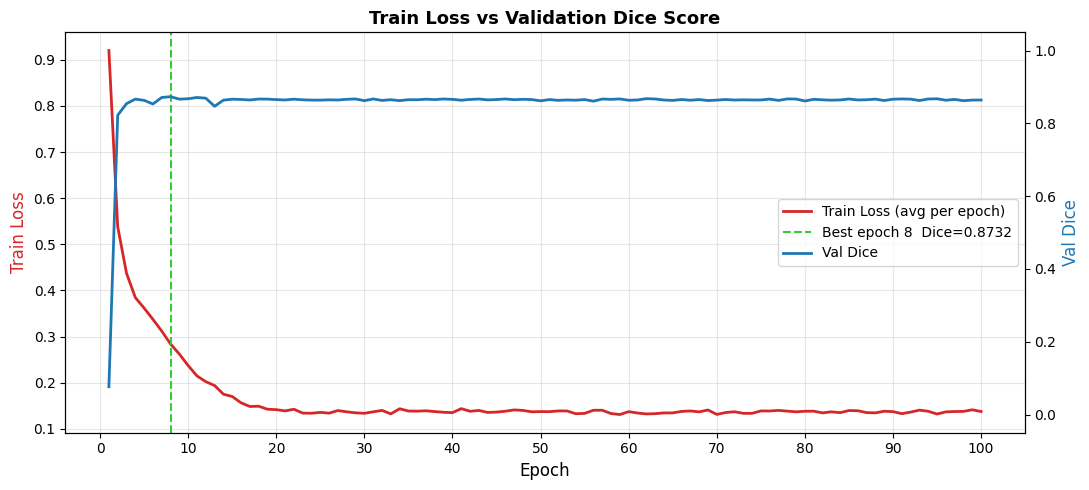


Summary  |  Best epoch: 8  |  Best Dice: 0.8732  |  Final loss: 0.1376


In [12]:
import os
os.environ['WANDB_MODE'] = 'disabled'

# !python train.py --epochs 100 --batch-size 16 --learning-rate 0.0001 --scale 0.5 --amp
# !python train.py --epochs 100 --batch-size 1 --learning-rate 0.001 --scale 0.5 --amp
# !python train.py --epochs 100 --batch-size 2 --learning-rate 0.001 --scale 0.5 --amp
# !python train.py --epochs 100 --batch-size 2 --learning-rate 0.0001 --scale 0.5 --amp

import subprocess
import time
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict

# --- KONFIGURASI ---
SAVE_DIR    = '/kaggle/working/Pytorch-UNet/checkpoints'
HISTORY_CSV = os.path.join(SAVE_DIR, 'training_history.csv')
os.makedirs(SAVE_DIR, exist_ok=True)     

cmd = [
    "python", "train.py",
    "--epochs", "100",
    "--batch-size", "4", 
    # "--learning-rate", "0.001", 
    "--learning-rate", "0.001",
    "--scale", "0.5", 
    "--amp"
]

print('Starting:', ' '.join(cmd))
t0 = time.time()

proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
    cwd='/kaggle/working/Pytorch-UNet',
)
for line in proc.stdout:
    print(line, end='')
proc.wait()
print(f'\nFinished in {time.time()-t0:.1f}s')

# ── Load history from CSV (written directly by train.py) ─────────────────────
if not os.path.exists(HISTORY_CSV):
    raise FileNotFoundError(
        f"CSV not found at {HISTORY_CSV}. "
        "Ensure Cell 3 ran and training completed without errors."
    )

history_df = pd.read_csv(HISTORY_CSV)
print(f"Loaded {len(history_df)} epoch rows.")
print(history_df.tail())

# ── Plot ──────────────────────────────────────────────────────────────────────
ep   = history_df['epoch'].values
loss = history_df['train_loss'].values
dice = history_df['val_dice'].values
bi   = int(np.argmax(dice))

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(ep, loss, color='tab:red',  lw=2, label='Train Loss (avg per epoch)')
ax2.plot(ep, dice, color='tab:blue', lw=2, label='Val Dice')
ax2.set_ylim(-0.05, 1.05)
ax1.axvline(ep[bi], color='limegreen', ls='--', lw=1.5,
            label=f'Best epoch {ep[bi]}  Dice={dice[bi]:.4f}')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Train Loss', color='tab:red',  fontsize=12)
ax2.set_ylabel('Val Dice',   color='tab:blue', fontsize=12)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))

all_lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(all_lines, [l.get_label() for l in all_lines],
           loc='center right', fontsize=10)
plt.title('Train Loss vs Validation Dice Score', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'train_val_curve.png'), dpi=150)
plt.show()
    
print(f"\nSummary  |  Best epoch: {ep[bi]}  |  Best Dice: {dice[bi]:.4f}  |  Final loss: {loss[-1]:.4f}")

In [13]:
import numpy as np
from PIL import Image 
img = np.asarray(Image.open('/kaggle/input/datasets/niqanabilanurihsani/phase-contrast-1000-80-20/train/images/218-4_part_10_tile_1.png'))
print(img.dtype, img.min(), img.max())

uint8 43 255


In [14]:
import os
from IPython.display import FileLink

# Pastikan kita berada di direktori /kaggle/working
os.chdir('/kaggle/working')

# Path menuju file model terbaik kamu
file_path = 'Pytorch-UNet/checkpoints/best_model_1024_musgd_final.pth'

if os.path.exists(file_path):
    print("File ditemukan! Klik link di bawah ini untuk mendownload:")
    display(FileLink(file_path))
else:
    print("!File tidak ditemukan. Pastikan proses training sudah selesai dan menyimpan model.")

File ditemukan! Klik link di bawah ini untuk mendownload:


/kaggle/working/Pytorch-UNet/checkpoints/best_model_1024_musgd_final.pth

/kaggle/working/Pytorch-UNet
📊 Loaded 100 epochs from CSV
📈 Graph saved to: /kaggle/working/Pytorch-UNet/checkpoints/train_val_curves_split.png


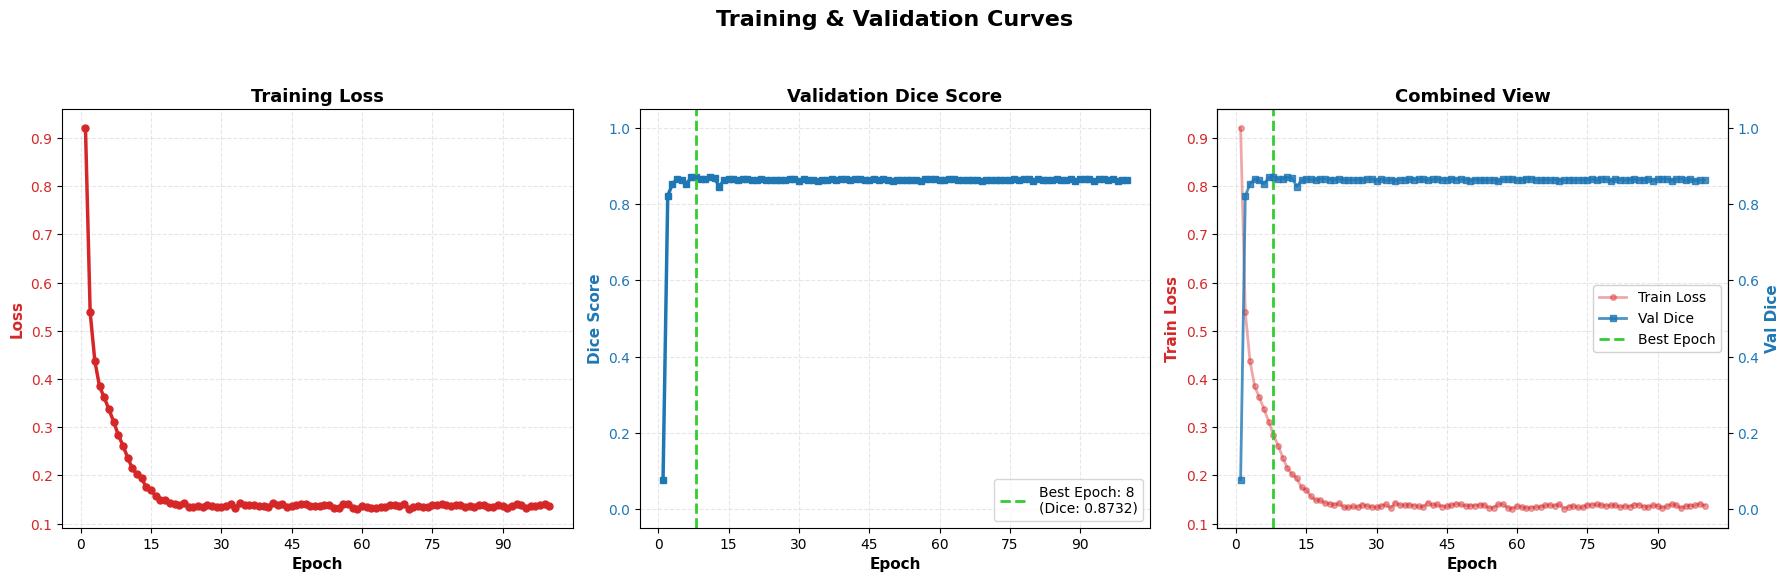


TRAINING SUMMARY
Best Epoch:       8
Best Dice Score:  0.8732
Final Train Loss: 0.1376
Final Val Dice:   0.8641

EVALUATING BEST MODEL ON TEST SET. PLEASE WAIT...


100%|██████████| 64/64 [00:01<00:00, 37.17it/s]


✅ Evaluated 64 test images.

  EVALUATION METRICS SUMMARY (TEST SET)
Mean Dice (F1-Score) : 0.8652
Mean IoU (Jaccard)   : 0.7717
Mean Precision       : 0.8814
Mean Recall          : 0.8545
Mean Percentage Error: 7.98 %


In [15]:
# ============================================================
# GRAPH GENERATOR (3-GRAPH LAYOUT) & FULL METRICS SUMMARY
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from collections import OrderedDict  
from torch.utils.data import DataLoader

# Pindah direktori agar bisa melakukan import modul U-Net
%cd /kaggle/working/Pytorch-UNet
from unet import UNet
from utils.data_loading import BasicDataset, CarvanaDataset

SAVE_DIR = '/kaggle/working/Pytorch-UNet/checkpoints'
HISTORY_CSV = os.path.join(SAVE_DIR, 'training_history.csv')

# ============================================================
# BAGIAN 1: LOAD DATA & PLOT GRAFIK TRAINING
# ============================================================
if not os.path.exists(HISTORY_CSV):
    raise FileNotFoundError(f"❌ CSV not found at {HISTORY_CSV}. You must run training first.")

history_df = pd.read_csv(HISTORY_CSV)
print(f'📊 Loaded {len(history_df)} epochs from CSV')

epochs = history_df['epoch'].values
train_loss = history_df['train_loss'].values
val_dice = history_df['val_dice'].values
best_idx = int(np.argmax(val_dice))

# Create 1x3 Plot Layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Training & Validation Curves', fontsize=16, fontweight='bold', y=1.05)

# --- PLOT 1: Train Loss Only ---
axes[0].plot(epochs, train_loss, color='tab:red', lw=2.5, marker='o', markersize=5)
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Loss', color='tab:red', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='y', labelcolor='tab:red')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- PLOT 2: Validation Dice Only ---
axes[1].plot(epochs, val_dice, color='tab:blue', lw=2.5, marker='s', markersize=5)
axes[1].axvline(epochs[best_idx], color='limegreen', ls='--', lw=2, 
                label=f'Best Epoch: {epochs[best_idx]}\n(Dice: {val_dice[best_idx]:.4f})')
axes[1].set_title('Validation Dice Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Dice Score', color='tab:blue', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='y', labelcolor='tab:blue')
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
axes[1].legend(loc='lower right')

# --- PLOT 3: Combined View ---
ax3 = axes[2]
ax3_twin = ax3.twinx()

line1 = ax3.plot(epochs, train_loss, color='tab:red', lw=2, label='Train Loss', marker='o', markersize=4, alpha=0.4)
line2 = ax3_twin.plot(epochs, val_dice, color='tab:blue', lw=2, label='Val Dice', marker='s', markersize=4, alpha=0.8)
line3 = ax3.axvline(epochs[best_idx], color='limegreen', ls='--', lw=2, label=f'Best Epoch')

ax3.set_title('Combined View', fontsize=13, fontweight='bold')
ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax3.set_ylabel('Train Loss', color='tab:red', fontsize=11, fontweight='bold')
ax3_twin.set_ylabel('Val Dice', color='tab:blue', fontsize=11, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='tab:red')
ax3_twin.tick_params(axis='y', labelcolor='tab:blue')
ax3_twin.set_ylim(-0.05, 1.05)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Merge legends for the combined plot
lines = line1 + line2 + [line3]
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='center right', fontsize=10, framealpha=0.9)

plt.tight_layout()

# Save and Show
save_path = os.path.join(SAVE_DIR, 'train_val_curves_split.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'📈 Graph saved to: {save_path}')
plt.show() 

# ============================================================
# BAGIAN 2: CETAK TRAINING SUMMARY
# ============================================================
print('\n' + '='*80)
print('TRAINING SUMMARY')
print('='*80)
print(f'Best Epoch:       {epochs[best_idx]}')
print(f'Best Dice Score:  {val_dice[best_idx]:.4f}')
print(f'Final Train Loss: {train_loss[-1]:.4f}')
print(f'Final Val Dice:   {val_dice[-1]:.4f}')

# ============================================================
# BAGIAN 3: EVALUASI METRIK PADA DATA TEST (SESUAI RUMUS TA)
# ============================================================
print('\n' + '='*80)
print('EVALUATING BEST MODEL ON TEST SET. PLEASE WAIT...')
print('='*80)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = os.path.join(SAVE_DIR, 'best_model_1024_musgd_final.pth')
TEST_IMG   = '/kaggle/input/datasets/niqanabilanurihsani/phase-contrast-1000-80-20/test/images'
TEST_MASK  = '/kaggle/input/datasets/niqanabilanurihsani/phase-contrast-1000-80-20/test/masks'
IMG_SCALE  = 0.5

# Load model
model = UNet(n_channels=1, n_classes=2, bilinear=False).to(DEVICE)
raw   = torch.load(MODEL_PATH, map_location=DEVICE)
sd    = OrderedDict((k.replace('module.',''), v) for k, v in raw.items() if k != 'mask_values')
model.load_state_dict(sd)
model.eval()

# Load Dataset
try:
    dataset = CarvanaDataset(TEST_IMG, TEST_MASK, IMG_SCALE)
except Exception:
    dataset = BasicDataset(TEST_IMG, TEST_MASK, IMG_SCALE)
loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

records = []
with torch.no_grad():
    for i, batch in enumerate(loader):
        imgs  = batch['image'].to(DEVICE)
        masks = batch['mask'].to(DEVICE)

        with torch.autocast(DEVICE.type, enabled=(DEVICE.type == 'cuda')):
            pred = model(imgs)

        pbin = (pred.argmax(dim=1) == 1).float().view(-1)
        tbin = (masks == 1).float().view(-1)

        TP = (pbin * tbin).sum().item()
        FP = (pbin * (1-tbin)).sum().item()
        FN = ((1-pbin) * tbin).sum().item()
        eps = 1e-8

        # Rumus sesuai Naskah
        precision = TP / (TP + FP + eps)
        recall    = TP / (TP + FN + eps)
        dice      = 2 * (precision * recall) / (precision + recall + eps)
        iou       = TP / (TP + FP + FN + eps)

        total_pixels = pbin.numel()
        WA_P  = (pbin.sum().item() / total_pixels) * 100.0
        WA_GT = (tbin.sum().item() / total_pixels) * 100.0
        percentage_error = abs(WA_P - WA_GT) / (WA_GT + eps) * 100.0

        records.append({
            'dice': dice, 'iou': iou, 'precision': precision,
            'recall': recall, 'percentage_error': percentage_error
        })

df_eval = pd.DataFrame(records)

print(f"✅ Evaluated {len(dataset)} test images.")
print("\n" + "="*80)
print("  EVALUATION METRICS SUMMARY (TEST SET)")
print("="*80)
print(f"Mean Dice (F1-Score) : {df_eval.dice.mean():.4f}")
print(f"Mean IoU (Jaccard)   : {df_eval.iou.mean():.4f}")
print(f"Mean Precision       : {df_eval.precision.mean():.4f}")
print(f"Mean Recall          : {df_eval.recall.mean():.4f}")
print(f"Mean Percentage Error: {df_eval.percentage_error.mean():.2f} %")
print("="*80)

/kaggle/working/Pytorch-UNet
Model loaded: /kaggle/working/Pytorch-UNet/checkpoints/best_model_1024_musgd_final.pth


100%|██████████| 64/64 [00:01<00:00, 47.34it/s]


Test set: 64 images. Running inference...



/tmp/ipykernel_58/1677771323.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([df[m].values for m in METRICS], labels=METRICS, patch_artist=True,


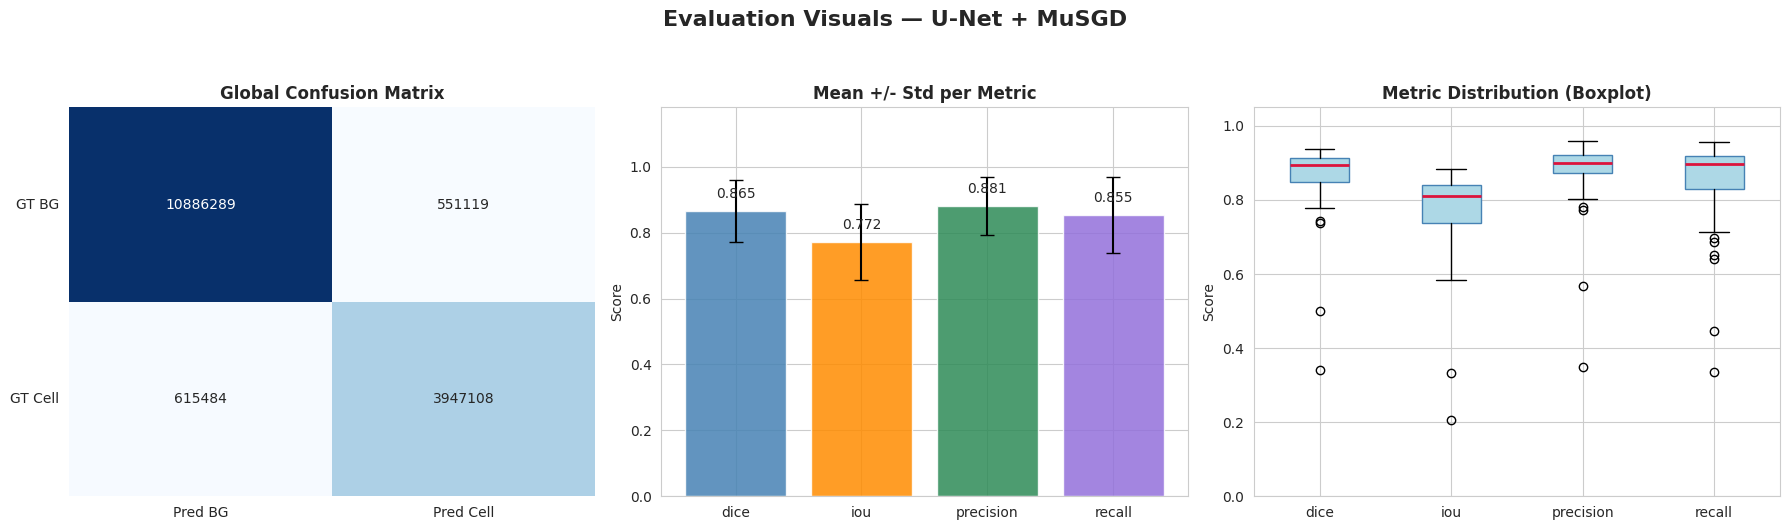

✅ Graph visual saved: /kaggle/working/Pytorch-UNet/checkpoints/evaluation_visuals_3grid.png


In [16]:
# ============================================================
# Evaluation visuals (1x3 Grid)
# ============================================================

import os, time
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
from torch.utils.data import DataLoader

%cd /kaggle/working/Pytorch-UNet
from unet import UNet
from utils.data_loading import BasicDataset, CarvanaDataset

# ── CONFIG ────────────────────────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = '/kaggle/working/Pytorch-UNet/checkpoints/best_model_1024_musgd_final.pth'
TEST_IMG   = '/kaggle/input/datasets/niqanabilanurihsani/phase-contrast-1000-80-20/test/images'
TEST_MASK  = '/kaggle/input/datasets/niqanabilanurihsani/phase-contrast-1000-80-20/test/masks'
IMG_SCALE  = 0.5
SAVE_DIR   = '/kaggle/working/Pytorch-UNet/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Load model ─────────────────────────────────────────────────────────────
model = UNet(n_channels=1, n_classes=2, bilinear=False).to(DEVICE)
raw   = torch.load(MODEL_PATH, map_location=DEVICE)
sd    = OrderedDict((k.replace('module.',''), v)
                    for k, v in raw.items() if k != 'mask_values')
model.load_state_dict(sd)
model.eval()
print(f"Model loaded: {MODEL_PATH}")

# ── 2. Load test data ─────────────────────────────────────────────────────────
try:
    dataset = CarvanaDataset(TEST_IMG, TEST_MASK, IMG_SCALE)
except Exception:
    dataset = BasicDataset(TEST_IMG, TEST_MASK, IMG_SCALE)
loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
print(f"Test set: {len(dataset)} images. Running inference...\n")

# ── 3. Inference ──────────────────────────────────────────────────────────────
records = []
gTP = gFP = gFN = gTN = 0.0

with torch.no_grad():
    for i, batch in enumerate(loader):
        imgs  = batch['image'].to(DEVICE)
        masks = batch['mask'].to(DEVICE)

        t0 = time.time()
        with torch.autocast(DEVICE.type, enabled=(DEVICE.type == 'cuda')):
            pred = model(imgs)
        infer_ms = (time.time() - t0) * 1000.0

        pbin = (pred.argmax(dim=1) == 1).float().view(-1)
        tbin = (masks == 1).float().view(-1)

        TP = (pbin * tbin).sum().item()
        FP = (pbin * (1-tbin)).sum().item()
        FN = ((1-pbin) * tbin).sum().item()
        TN = ((1-pbin) * (1-tbin)).sum().item()
        gTP+=TP; gFP+=FP; gFN+=FN; gTN+=TN

        eps = 1e-8
        records.append({
            'img'      : i+1,
            'dice'     : (2*TP)/(2*TP+FP+FN+eps),
            'iou'      : TP/(TP+FP+FN+eps),
            'precision': TP/(TP+FP+eps),
            'recall'   : TP/(TP+FN+eps),
            'infer_ms' : infer_ms,
        })

df = pd.DataFrame(records)

# ── 4. Plots (1x3 Grid) ───────────────────────────────────────────────────────
METRICS = ['dice','iou','precision','recall']
COLORS  = ['steelblue','darkorange','seagreen','mediumpurple']
sns.set_style('whitegrid')

# Create a clean 1x3 layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluation Visuals — U-Net + MuSGD',
             fontsize=16, fontweight='bold', y=1.05)

# Plot 1: Confusion matrix
cm = np.array([[int(gTN),int(gFP)],[int(gFN),int(gTP)]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred BG','Pred Cell'],
            yticklabels=['GT BG','GT Cell'], ax=axes[0])
axes[0].set_title('Global Confusion Matrix', fontweight='bold')
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Mean +/- Std Bar Chart
means = [df[m].mean() for m in METRICS]
stds  = [df[m].std()  for m in METRICS]
bars  = axes[1].bar(METRICS, means, yerr=stds, capsize=5,
               color=COLORS, alpha=0.85, edgecolor='white')
axes[1].set_ylim(0, 1.18)
axes[1].set_ylabel('Score')
axes[1].set_title('Mean +/- Std per Metric', fontweight='bold')
for b, v in zip(bars, means):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.03, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=10)

# Plot 3: Boxplot  
axes[2].boxplot([df[m].values for m in METRICS], labels=METRICS, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='crimson', lw=2))
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel('Score')
axes[2].set_title('Metric Distribution (Boxplot)', fontweight='bold')

plt.tight_layout()
out_path = os.path.join(SAVE_DIR, 'evaluation_visuals_3grid.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Graph visual saved: {out_path}")

/kaggle/working/Pytorch-UNet
Model loaded: /kaggle/working/Pytorch-UNet/checkpoints/best_model_1024_musgd_final.pth


100%|██████████| 64/64 [00:01<00:00, 47.99it/s]


Test set: 64 images. Running inference...

  EVALUATION SUMMARY (SESUAI RUMUS DOKUMEN)
Mean Dice (F1-Score) : 0.8652
Mean IoU (Jaccard)   : 0.7717
Mean Precision       : 0.8814
Mean Recall          : 0.8545
Mean Percentage Error: 7.98%


/tmp/ipykernel_58/2176832717.py:147: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([df[m].values for m in METRICS], labels=METRICS, patch_artist=True,


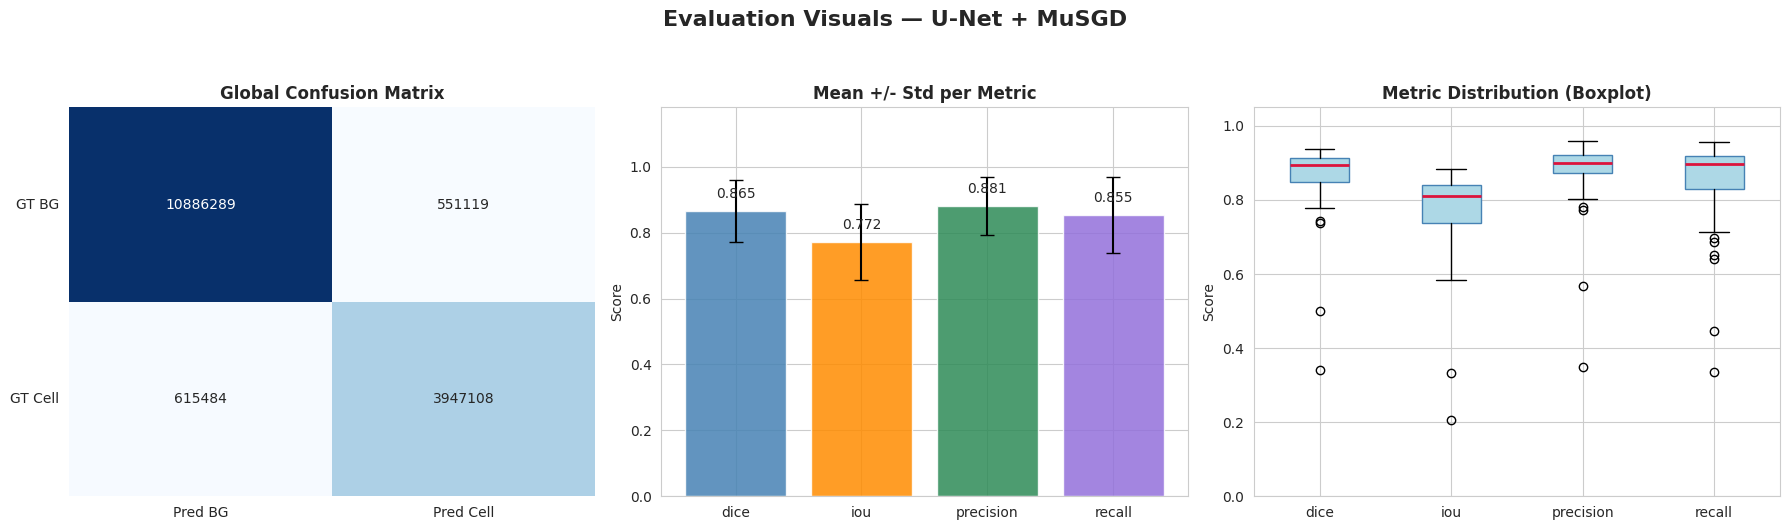

✅ Graph visual saved: /kaggle/working/Pytorch-UNet/checkpoints/evaluation_visuals_3grid.png


In [17]:
# ============================================================
# Evaluation visuals (1x3 Grid) - FORMULA MATCHED
# ============================================================

import os, time
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
from torch.utils.data import DataLoader

%cd /kaggle/working/Pytorch-UNet
from unet import UNet
from utils.data_loading import BasicDataset, CarvanaDataset

# ── CONFIG ────────────────────────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = '/kaggle/working/Pytorch-UNet/checkpoints/best_model_1024_musgd_final.pth'
TEST_IMG   = '/kaggle/input/datasets/niqanabilanurihsani/phase-contrast-1000-80-20/test/images'
TEST_MASK  = '/kaggle/input/datasets/niqanabilanurihsani/phase-contrast-1000-80-20/test/masks'
IMG_SCALE  = 0.5
SAVE_DIR   = '/kaggle/working/Pytorch-UNet/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Load model ─────────────────────────────────────────────────────────────
model = UNet(n_channels=1, n_classes=2, bilinear=False).to(DEVICE)
raw   = torch.load(MODEL_PATH, map_location=DEVICE)
sd    = OrderedDict((k.replace('module.',''), v)
                    for k, v in raw.items() if k != 'mask_values')
model.load_state_dict(sd)
model.eval()
print(f"Model loaded: {MODEL_PATH}")

# ── 2. Load test data ─────────────────────────────────────────────────────────
try:
    dataset = CarvanaDataset(TEST_IMG, TEST_MASK, IMG_SCALE)
except Exception:
    dataset = BasicDataset(TEST_IMG, TEST_MASK, IMG_SCALE)
loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
print(f"Test set: {len(dataset)} images. Running inference...\n")

# ── 3. Inference & Mathematical Formulas ──────────────────────────────────────
records = []
gTP = gFP = gFN = gTN = 0.0

with torch.no_grad():
    for i, batch in enumerate(loader):
        imgs  = batch['image'].to(DEVICE)
        masks = batch['mask'].to(DEVICE)

        t0 = time.time()
        with torch.autocast(DEVICE.type, enabled=(DEVICE.type == 'cuda')):
            pred = model(imgs)
        infer_ms = (time.time() - t0) * 1000.0

        pbin = (pred.argmax(dim=1) == 1).float().view(-1)
        tbin = (masks == 1).float().view(-1)

        # Matriks TP, FP, FN, TN
        TP = (pbin * tbin).sum().item()
        FP = (pbin * (1-tbin)).sum().item()
        FN = ((1-pbin) * tbin).sum().item()
        TN = ((1-pbin) * (1-tbin)).sum().item()
        
        gTP+=TP; gFP+=FP; gFN+=FN; gTN+=TN
        eps = 1e-8

        # =========================================================
        # KALKULASI SESUAI NASKAH TUGAS AKHIR (II.1.1)
        # =========================================================
        
        # 1. Precision & Recall
        precision = TP / (TP + FP + eps)
        recall    = TP / (TP + FN + eps)
        
        # 2. Dice Coefficient (F1-Score) -> Pendekatan Rata-rata Harmonik
        dice = 2 * (precision * recall) / (precision + recall + eps)
        
        # 3. Intersection over Union (IoU) / Jaccard Index
        iou = TP / (TP + FP + FN + eps)
        
        # 4. Confluence Estimation Percentage
        total_pixels = pbin.numel()
        WA_P  = (pbin.sum().item() / total_pixels) * 100.0  # WA(P)
        WA_GT = (tbin.sum().item() / total_pixels) * 100.0  # WA(GT)
        
        # 5. Percentage Error (PE)
        # | WA(P) - WA(GT) | / WA(GT) * 100%
        percentage_error = abs(WA_P - WA_GT) / (WA_GT + eps) * 100.0
        # =========================================================

        records.append({
            'img'             : i+1,
            'dice'            : dice,
            'iou'             : iou,
            'precision'       : precision,
            'recall'          : recall,
            'pred_confluence' : WA_P,
            'gt_confluence'   : WA_GT,
            'percentage_error': percentage_error,
            'infer_ms'        : infer_ms,
        })

df = pd.DataFrame(records)

# ── 4. Summary Output ─────────────────────────────────────────────────────────
print("="*60)
print("  EVALUATION SUMMARY (SESUAI RUMUS DOKUMEN)")
print("="*60)
print(f"Mean Dice (F1-Score) : {df.dice.mean():.4f}")
print(f"Mean IoU (Jaccard)   : {df.iou.mean():.4f}")
print(f"Mean Precision       : {df.precision.mean():.4f}")
print(f"Mean Recall          : {df.recall.mean():.4f}")
print(f"Mean Percentage Error: {df.percentage_error.mean():.2f}%")
print("="*60)

# ── 5. Plots (1x3 Grid) ───────────────────────────────────────────────────────
METRICS = ['dice','iou','precision','recall']
COLORS  = ['steelblue','darkorange','seagreen','mediumpurple']
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluation Visuals — U-Net + MuSGD',
             fontsize=16, fontweight='bold', y=1.05)

# Plot 1: Confusion matrix
cm = np.array([[int(gTN),int(gFP)],[int(gFN),int(gTP)]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred BG','Pred Cell'],
            yticklabels=['GT BG','GT Cell'], ax=axes[0])
axes[0].set_title('Global Confusion Matrix', fontweight='bold')
axes[0].tick_params(axis='y', rotation=0)

# Plot 2: Mean +/- Std Bar Chart
means = [df[m].mean() for m in METRICS]
stds  = [df[m].std()  for m in METRICS]
bars  = axes[1].bar(METRICS, means, yerr=stds, capsize=5,
               color=COLORS, alpha=0.85, edgecolor='white')
axes[1].set_ylim(0, 1.18)
axes[1].set_ylabel('Score')
axes[1].set_title('Mean +/- Std per Metric', fontweight='bold')
for b, v in zip(bars, means):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.03, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=10)

# Plot 3: Boxplot
axes[2].boxplot([df[m].values for m in METRICS], labels=METRICS, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='crimson', lw=2))
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel('Score')
axes[2].set_title('Metric Distribution (Boxplot)', fontweight='bold')

plt.tight_layout()
out_path = os.path.join(SAVE_DIR, 'evaluation_visuals_3grid.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Graph visual saved: {out_path}")

In [18]:
# ============================================================
# Download Checkpoints Folder (FIXED)
# ============================================================
import os
import shutil
from IPython.display import FileLink, display

# 1. Force the notebook back to the main working directory
os.chdir('/kaggle/working') 

# 2. Define paths
folder_to_download = '/kaggle/working/Pytorch-UNet/checkpoints'
zip_filename = 'unet_checkpoints_AdamN_batch-size-4_final' # shutil will automatically add .zip

print(f"Compressing {folder_to_download}...")

# 3. Create the zip file
shutil.make_archive(zip_filename, 'zip', folder_to_download)

print("✅ Compression complete! Click the link below to download your files:")

# 4. Display the clickable download link explicitly
display(FileLink(f'{zip_filename}.zip'))

Compressing /kaggle/working/Pytorch-UNet/checkpoints...
✅ Compression complete! Click the link below to download your files:


/kaggle/working/unet_checkpoints_AdamN_batch-size-4_final.zip

In [19]:
# import os, re
 
# %cd /kaggle/working/Pytorch-UNet

# with open('train.py', 'r') as f:
#     content = f.read()

# # Memasukkan AdamW dengan lr=1e-3, wd=5e-4, dan betas=(0.9, 0.999)
# new_opt = "optimizer = optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=0.0005)"

# content = re.sub(r"optimizer = optim\.RMSprop\([\s\S]*?foreach=True\)", new_opt, content)

# with open('train.py', 'w') as f:
#     f.write(content)

# print("✅ train.py dipatch ke: AdamW (LR=1e-3, WD=5e-4, Betas=(0.9, 0.999))")

#####################################################################################################################################################

import os, re

%cd /kaggle/working/Pytorch-UNet

with open('train.py', 'r') as f:
    content = f.read()

pattern = r"optimizer\s*=\s*optim\.RMSprop\([\s\S]*?foreach=True\s*\)"

# Memasukkan AdamW dengan lr dan wd sama, betas=(0.9, 0.999)
# new_opt = "optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay, betas=(0.9, 0.999))"
new_opt = (
    "optimizer = optim.AdamW("
    "model.parameters(), "
    "lr=learning_rate, "
    "weight_decay=weight_decay, "
    "betas=(0.9, 0.999), "
    "foreach=True)"
)

# content = re.sub(r"optimizer = optim\.RMSprop\([\s\S]*?foreach=True\)", new_opt, content)
content = re.sub(pattern, new_opt, content)

with open('train.py', 'w') as f:
    f.write(content)

print("✅ train.py dipatch ke: AdamW (LR dan WD sama, Betas=(0.9, 0.999))")

/kaggle/working/Pytorch-UNet
✅ train.py dipatch ke: AdamW (LR dan WD sama, Betas=(0.9, 0.999))
